In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

DATASET_PATH = "data/arxiv-metadata-oai-snapshot.json"
SAMPLE_SIZE  = 5000
RANDOM_SEED  = 42
np.random.seed(RANDOM_SEED)

print(f"Dataset : {DATASET_PATH}")
print(f"Sample  : {SAMPLE_SIZE} papers")
print(f"Seed    : {RANDOM_SEED}")

Dataset : data/arxiv-metadata-oai-snapshot.json
Sample  : 5000 papers
Seed    : 42


### 1.Data Loading

In [3]:
rows = []
with open(DATASET_PATH, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= SAMPLE_SIZE:
            break
        try:
            p = json.loads(line)
            rows.append({
                'id'         : p.get('id', ''),
                'title'      : p.get('title', '').replace('\n', ' ').strip(),
                'abstract'   : p.get('abstract', '').replace('\n', ' ').strip(),
                'authors'    : p.get('authors', ''),
                'submitter'  : p.get('submitter', ''),
                'categories' : p.get('categories', ''),
                'journal_ref': p.get('journal-ref', '') or '',
                'doi'        : p.get('doi', '') or '',
                'comments'   : p.get('comments', '') or '',
                'report_no'  : p.get('report-no', '') or '',
                'license'    : p.get('license', '') or '',
                'date'       : p.get('update_date', ''),
            })
        except:
            continue

df = pd.DataFrame(rows)

print(f"Dataset loaded")
print(f"Shape      : {df.shape}")
print(f"Columns    : {list(df.columns)}")
print(f"\nSample entry:")
print(f"   ID         : {df['id'].iloc[0]}")
print(f"   Title      : {df['title'].iloc[0][:60]}...")
print(f"   Abstract   : {df['abstract'].iloc[0][:80]}...")
print(f"   Authors    : {df['authors'].iloc[0][:50]}...")
print(f"   Submitter  : {df['submitter'].iloc[0]}")
print(f"   Categories : {df['categories'].iloc[0]}")
print(f"   Journal    : {df['journal_ref'].iloc[0]}")
print(f"   DOI        : {df['doi'].iloc[0]}")
print(f"   Comments   : {df['comments'].iloc[0]}")
print(f"   Report No  : {df['report_no'].iloc[0]}")
print(f"   License    : {df['license'].iloc[0]}")
print(f"   Date       : {df['date'].iloc[0]}")
df.head(3)


Dataset loaded
Shape      : (5000, 12)
Columns    : ['id', 'title', 'abstract', 'authors', 'submitter', 'categories', 'journal_ref', 'doi', 'comments', 'report_no', 'license', 'date']

Sample entry:
   ID         : 0704.0001
   Title      : Calculation of prompt diphoton production cross sections at ...
   Abstract   : A fully differential calculation in perturbative quantum chromodynamics is prese...
   Authors    : C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-P. Y...
   Submitter  : Pavel Nadolsky
   Categories : hep-ph
   Journal    : Phys.Rev.D76:013009,2007
   DOI        : 10.1103/PhysRevD.76.013009
   Comments   : 37 pages, 15 figures; published version
   Report No  : ANL-HEP-PR-07-12
   License    : 
   Date       : 2008-11-26


,id,title,abstract,authors,submitter,categories,journal_ref,doi,comments,report_no,license,date
0,0704.0001,Calculation of prompt diphoton production cros...,A fully differential calculation in perturbati...,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...",Pavel Nadolsky,hep-ph,"Phys.Rev.D76:013009,2007",10.1103/PhysRevD.76.013009,"37 pages, 15 figures; published version",ANL-HEP-PR-07-12,,2008-11-26
1,0704.0002,Sparsity-certifying Graph Decompositions,"We describe a new algorithm, the $(k,\ell)$-pe...",Ileana Streinu and Louis Theran,Louis Theran,math.CO cs.CG,,,To appear in Graphs and Combinatorics,,http://arxiv.org/licenses/nonexclusive-distrib...,2008-12-13
2,0704.0003,The evolution of the Earth-Moon system based o...,The evolution of Earth-Moon system is describe...,Hongjun Pan,Hongjun Pan,physics.gen-ph,,,"23 pages, 3 figures",,,2008-01-13


### 2.Exploration Data

**2.1 : Basic Statistics**

In [4]:
print(f"   Total papers     : {len(df)}")
print(f"   Total columns    : {df.shape[1]}")
print(f"   Missing values   :\n{df.isnull().sum()}")
print(f"\n   Data types :\n{df.dtypes}")

   Total papers     : 5000
   Total columns    : 12
   Missing values   :
id             0
title          0
abstract       0
authors        0
submitter      0
categories     0
journal_ref    0
doi            0
comments       0
report_no      0
license        0
date           0
dtype: int64

   Data types :
id             object
title          object
abstract       object
authors        object
submitter      object
categories     object
journal_ref    object
doi            object
comments       object
report_no      object
license        object
date           object
dtype: object


**2.2 : Category Distribution**



   Unique main categories : 18

   Top 10 categories :
main_category
math        999
astro-ph    972
cond-mat    898
physics     345
hep-ph      326
hep-th      305
quant-ph    257
cs          250
gr-qc       166
math-ph     101
Name: count, dtype: int64


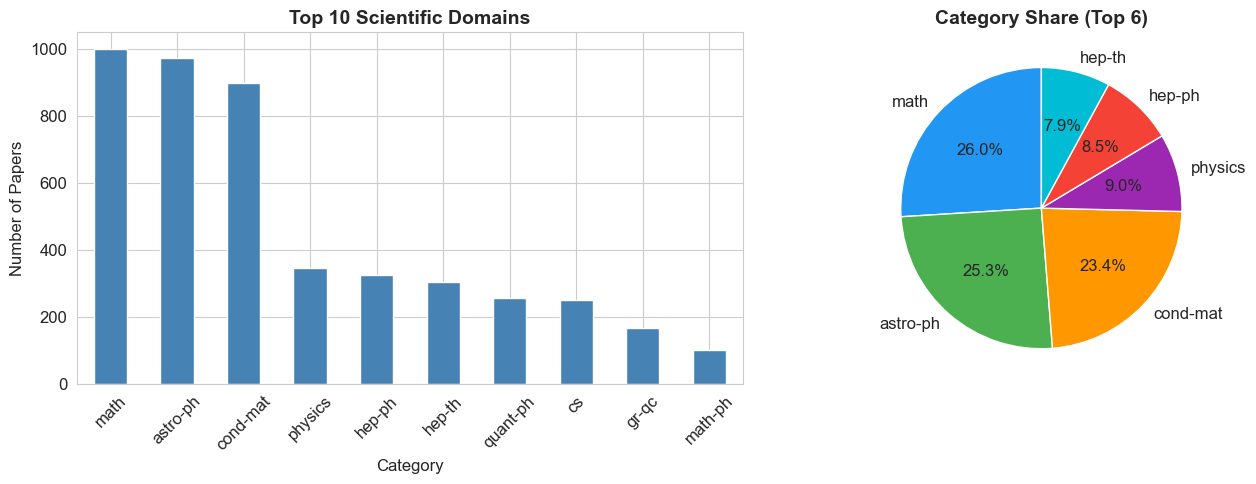

 Plot saved → reports/category_distribution.png


In [5]:
# Extract main category 
df['main_category'] = df['categories'].apply(
    lambda x: x.split()[0].split('.')[0] if x else 'unknown'
)

# Count
cat_counts = df['main_category'].value_counts()
print(f"\n   Unique main categories : {df['main_category'].nunique()}")
print(f"\n   Top 10 categories :\n{cat_counts.head(10)}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
cat_counts.head(10).plot(
    kind='bar', ax=axes[0],
    color='steelblue', edgecolor='white'
)
axes[0].set_title('Top 10 Scientific Domains', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Papers')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
cat_counts.head(6).plot(
    kind='pie', ax=axes[1],
    autopct='%1.1f%%',
    colors=['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4'],
    startangle=90
)
axes[1].set_title('Category Share (Top 6)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('reports/category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved → reports/category_distribution.png")

**2.3 : Abstract Length Distribution**



 Average words per abstract  : 122.1
   Min words                   : 2
   Max words                   : 318
   Average chars per abstract  : 802.5


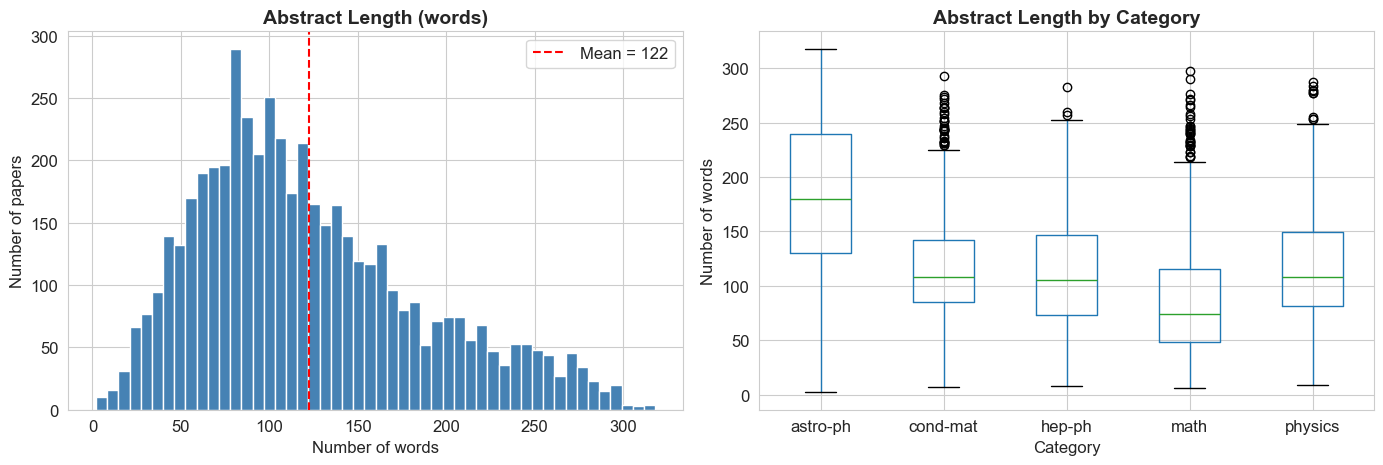

Plot saved → reports/abstract_length.png


In [6]:
# Count words and characters
df['nb_words']    = df['abstract'].apply(lambda x: len(x.split()))
df['nb_chars']    = df['abstract'].apply(lambda x: len(x))

print(f"\n Average words per abstract  : {df['nb_words'].mean():.1f}")
print(f"   Min words                   : {df['nb_words'].min()}")
print(f"   Max words                   : {df['nb_words'].max()}")
print(f"   Average chars per abstract  : {df['nb_chars'].mean():.1f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count distribution
axes[0].hist(df['nb_words'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df['nb_words'].mean(), color='red', linestyle='--', 
                label=f"Mean = {df['nb_words'].mean():.0f}")
axes[0].set_title('Abstract Length (words)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of words')
axes[0].set_ylabel('Number of papers')
axes[0].legend()

# Boxplot by category
top5_cats = df['main_category'].value_counts().head(5).index
df_top5   = df[df['main_category'].isin(top5_cats)]
df_top5.boxplot(column='nb_words', by='main_category', ax=axes[1])
axes[1].set_title('Abstract Length by Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Number of words')
plt.suptitle('')

plt.tight_layout()
plt.savefig('reports/abstract_length.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → reports/abstract_length.png")

**2.4 : Word Cloud**


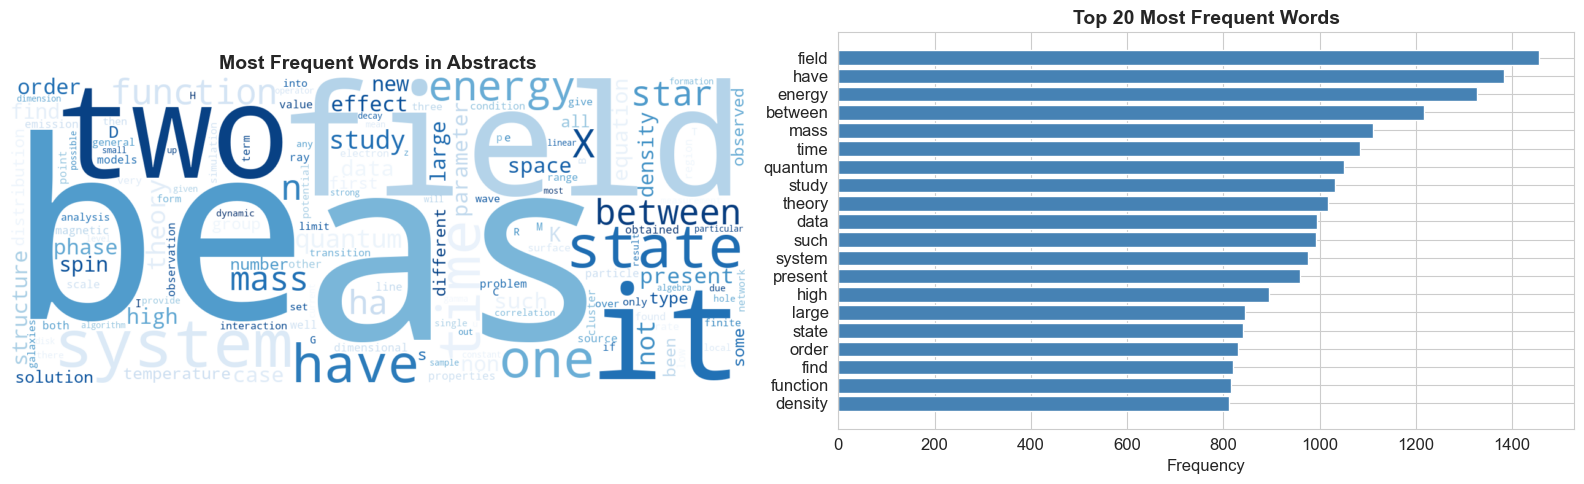

Plot saved → reports/wordcloud.png


In [7]:
from wordcloud import WordCloud

# Combine all abstracts into one text
all_text = ' '.join(df['abstract'].tolist())

# Remove common words that are not useful
custom_stopwords = {
    'the','a','an','and','or','but','in','on','at','to',
    'for','of','with','by','from','is','are','was','were',
    'this','that','these','those','we','our','their','its',
    'also','however','thus','hence','while','since','using',
    'used','use','show','shown','shows','based','paper',
    'propose','proposed','method','approach','model','results',
    'can','may','which','where','when','how','than','more'
}

# Generate word cloud
wc = WordCloud(
    width=1200, height=500,
    background_color='white',
    max_words=150,
    stopwords=custom_stopwords,
    colormap='Blues',
    collocations=False
).generate(all_text)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Word cloud
axes[0].imshow(wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most Frequent Words in Abstracts',
                  fontsize=14, fontweight='bold')

# Top 20 most frequent words bar chart
from collections import Counter
import re

words = re.findall(r'\b[a-z]{4,}\b', all_text.lower())
words = [w for w in words if w not in custom_stopwords]
top_words = Counter(words).most_common(20)

words_list  = [w[0] for w in top_words]
counts_list = [w[1] for w in top_words]

axes[1].barh(words_list[::-1], counts_list[::-1], color='steelblue')
axes[1].set_title('Top 20 Most Frequent Words',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('reports/wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → reports/wordcloud.png")

**2.5 : Publication Trends Over Time**


   Year range : 2007 → 2025
   Papers with valid date : 5000


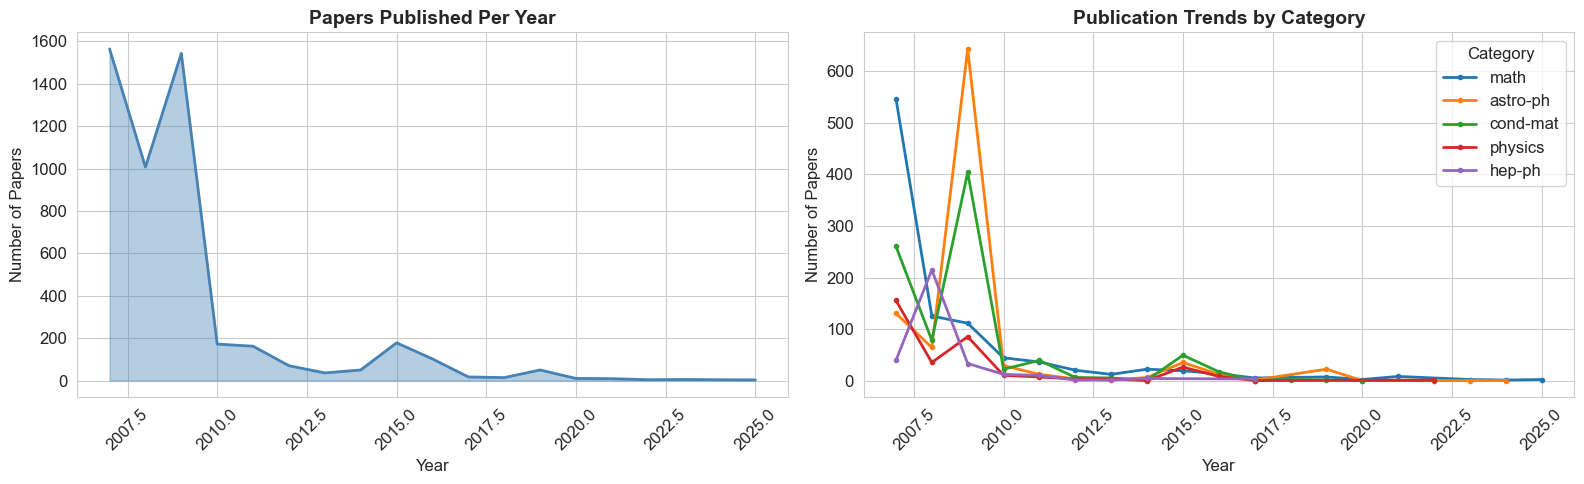

Plot saved → reports/publication_trends.png


In [8]:
# Extract year from date column
df['year'] = pd.to_datetime(df['date'], errors='coerce').dt.year

# Remove invalid years
df_valid = df[df['year'].between(1990, 2025)]

print(f"   Year range : {df_valid['year'].min()} → {df_valid['year'].max()}")
print(f"   Papers with valid date : {len(df_valid)}")

# Count papers per year
papers_per_year = df_valid['year'].value_counts().sort_index()

# Count papers per year per category (top 5)
top5_cats = df['main_category'].value_counts().head(5).index
df_top5   = df_valid[df_valid['main_category'].isin(top5_cats)]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total papers per year
axes[0].fill_between(papers_per_year.index, papers_per_year.values,
                     alpha=0.4, color='steelblue')
axes[0].plot(papers_per_year.index, papers_per_year.values,
             color='steelblue', linewidth=2)
axes[0].set_title('Papers Published Per Year',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Papers')
axes[0].tick_params(axis='x', rotation=45)

# Papers per year by category
for cat in top5_cats:
    cat_data = df_top5[df_top5['main_category'] == cat]
    yearly   = cat_data['year'].value_counts().sort_index()
    axes[1].plot(yearly.index, yearly.values, marker='o',
                 markersize=3, linewidth=2, label=cat)

axes[1].set_title('Publication Trends by Category',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Papers')
axes[1].legend(title='Category')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('reports/publication_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → reports/publication_trends.png")

**2.6 : Correlation Heatmap**


   Numerical features created :
   - nb_words        : word count of abstract
   - nb_chars        : character count of abstract
   - nb_authors      : number of authors
   - has_journal     : has journal reference (0/1)
   - has_doi         : has DOI (0/1)
   - has_comments    : has comments (0/1)
   - abstract_density: words/chars ratio
   - year            : publication year


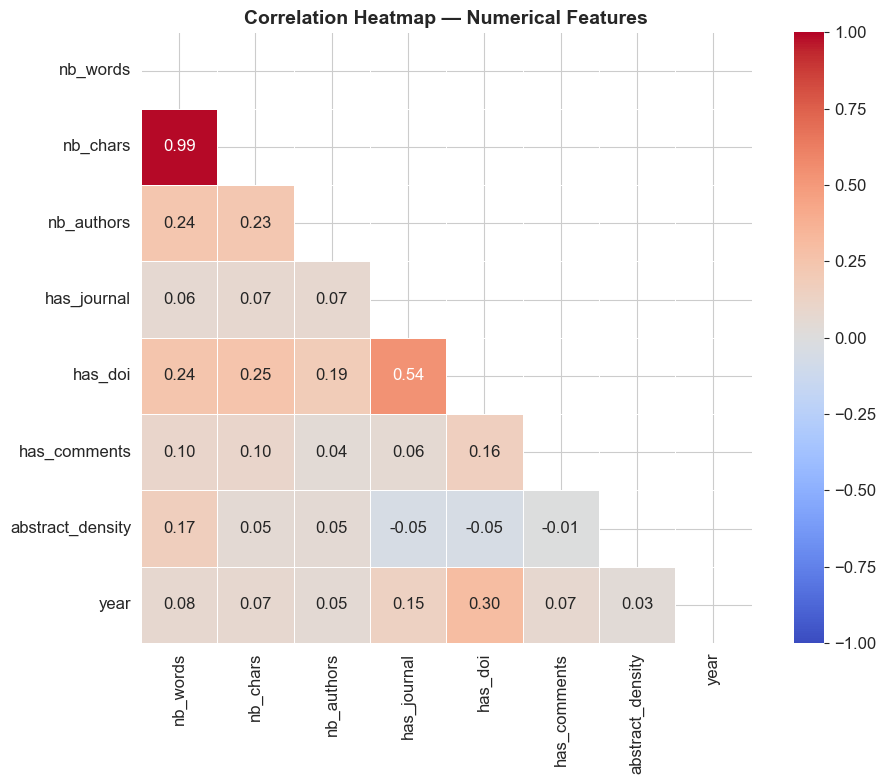

 Plot saved → reports/correlation_heatmap.png

  EDA COMPLETE — Key Insights
  • Dataset    : 5000 papers, 21 features
  • Categories : 18 unique domains
  • Top domain : math
  • Avg abstract length : 122 words
  • Year range : 2007 → 2025
  • 4 plots saved in reports/


In [9]:
# Create numerical features for correlation
df['nb_authors']     = df['authors'].apply(lambda x: len(x.split(',')) if x else 0)
df['has_journal']    = (df['journal_ref'] != '').astype(int)
df['has_doi']        = (df['doi'] != '').astype(int)
df['has_comments']   = (df['comments'] != '').astype(int)
df['abstract_density'] = df['nb_words'] / df['nb_chars'].replace(0, 1)

print(f"\n   Numerical features created :")
print(f"   - nb_words        : word count of abstract")
print(f"   - nb_chars        : character count of abstract")
print(f"   - nb_authors      : number of authors")
print(f"   - has_journal     : has journal reference (0/1)")
print(f"   - has_doi         : has DOI (0/1)")
print(f"   - has_comments    : has comments (0/1)")
print(f"   - abstract_density: words/chars ratio")
print(f"   - year            : publication year")

# Select numerical columns
num_cols = ['nb_words', 'nb_chars', 'nb_authors',
            'has_journal', 'has_doi', 'has_comments',
            'abstract_density', 'year']

corr_matrix = df[num_cols].corr()

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Heatmap — Numerical Features',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('reports/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved → reports/correlation_heatmap.png")

# EDA Summary
print("\n" + "=" * 60)
print("  EDA COMPLETE — Key Insights")
print("=" * 60)
print(f"  • Dataset    : {len(df)} papers, {df.shape[1]} features")
print(f"  • Categories : {df['main_category'].nunique()} unique domains")
print(f"  • Top domain : {df['main_category'].value_counts().index[0]}")
print(f"  • Avg abstract length : {df['nb_words'].mean():.0f} words")
print(f"  • Year range : {df['year'].min():.0f} → {df['year'].max():.0f}")
print(f"  • 4 plots saved in reports/")
print("=" * 60)

### 3.Data Preprocessing

In [10]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK data
nltk.download('punkt',       quiet=True)
nltk.download('stopwords',   quiet=True)
nltk.download('wordnet',     quiet=True)
nltk.download('punkt_tab',   quiet=True)

True

**3.1 : Define cleaning pipeline**

In [11]:
STOPWORDS   = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def clean_text(text):
    """Full text cleaning pipeline"""
    if not isinstance(text, str):
        return ''

    # Step 1 — Lowercase
    text = text.lower()

    # Step 2 — Remove LaTeX formulas
    text = re.sub(r'\$[^$]+\$', ' ', text)
    text = re.sub(r'\\[a-zA-Z]+\{[^}]*\}', ' ', text)

    # Step 3 — Remove special characters, keep only letters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Step 4 — Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 5 — Tokenize
    tokens = word_tokenize(text)

    # Step 6 — Remove stopwords + short words
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]

    # Step 7 — Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)


**3.2 : Apply and Verify**


100%|██████████| 5000/5000 [00:01<00:00, 2837.21it/s]



  Cleaning complete!
   Papers cleaned : 5000

 Before vs After cleaning , 2 examples :
------------------------------------------------------------

   Example 1 :
   BEFORE : A fully differential calculation in perturbative quantum chromodynamics is presented for the production of massive photon pairs at hadron colliders. A...
   AFTER  : fully differential calculation perturbative quantum chromodynamics presented production massive photon pair hadron collider next leading order perturb...


   Example 2 :
   BEFORE : We describe a new algorithm, the $(k,\ell)$-pebble game with colors, and use it obtain a characterization of the family of $(k,\ell)$-sparse graphs an...
   AFTER  : describe new algorithm pebble game color use obtain characterization family sparse graph algorithmic solution family problem concerning tree decomposi...

------------------------------------------------------------

 Stats after cleaning :
   Avg words BEFORE : 122
   Avg words AFTER  : 70
   Reduction   

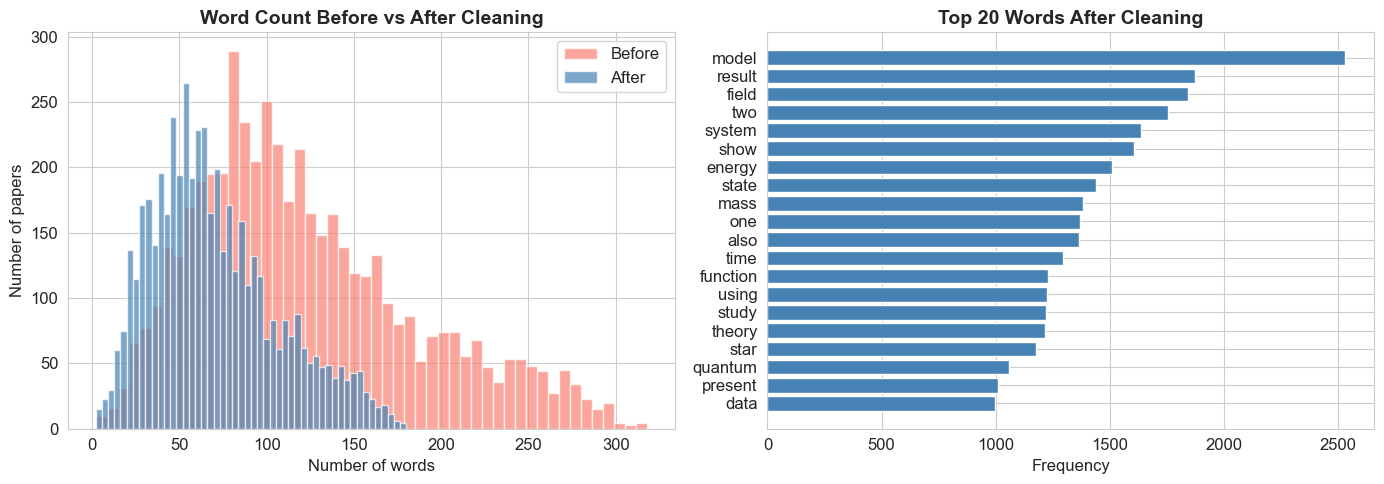

  • abstract_clean : cleaned abstract text
  • title_clean    : cleaned title text
  • Noise removed  : LaTeX, special chars, stopwords
  • Plot saved     → reports/preprocessing_comparison.png


In [12]:
from tqdm import tqdm
tqdm.pandas()

# Apply cleaning to all abstracts
df['abstract_clean'] = df['abstract'].progress_apply(clean_text)

# Also clean titles
df['title_clean'] = df['title'].progress_apply(clean_text)

print(f"\n  Cleaning complete!")
print(f"   Papers cleaned : {len(df)}")

#  Verify before / after
print("\n Before vs After cleaning , 2 examples :")
print("-" * 60)

for i in [0, 1]:
    print(f"\n   Example {i+1} :")
    print(f"   BEFORE : {df['abstract'].iloc[i][:150]}...")
    print(f"   AFTER  : {df['abstract_clean'].iloc[i][:150]}...")
    print()

# Stats after cleaning
df['nb_words_clean'] = df['abstract_clean'].apply(lambda x: len(x.split()))

print("-" * 60)
print(f"\n Stats after cleaning :")
print(f"   Avg words BEFORE : {df['nb_words'].mean():.0f}")
print(f"   Avg words AFTER  : {df['nb_words_clean'].mean():.0f}")
print(f"   Reduction        : {((df['nb_words'].mean() - df['nb_words_clean'].mean()) / df['nb_words'].mean() * 100):.1f}%")

# Plot before vs after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['nb_words'],       bins=50, color='salmon',    
             edgecolor='white', alpha=0.7, label='Before')
axes[0].hist(df['nb_words_clean'], bins=50, color='steelblue', 
             edgecolor='white', alpha=0.7, label='After')
axes[0].set_title('Word Count Before vs After Cleaning',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of words')
axes[0].set_ylabel('Number of papers')
axes[0].legend()

# Top words after cleaning
from collections import Counter
import re as re2

all_clean = ' '.join(df['abstract_clean'].tolist())
words_clean = all_clean.split()
top20_clean = Counter(words_clean).most_common(20)

words_list  = [w[0] for w in top20_clean]
counts_list = [w[1] for w in top20_clean]

axes[1].barh(words_list[::-1], counts_list[::-1], color='steelblue')
axes[1].set_title('Top 20 Words After Cleaning',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('reports/preprocessing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print(f"  • abstract_clean : cleaned abstract text")
print(f"  • title_clean    : cleaned title text")
print(f"  • Noise removed  : LaTeX, special chars, stopwords")
print(f"  • Plot saved     → reports/preprocessing_comparison.png")
print("=" * 60)

### 4.Feature Engineering

**4.1 : Text-based Features**

In [13]:
df['nb_sentences'] = df['abstract'].apply(
    lambda x: len(re.split(r'[.!?]', x)) if x else 0)

df['avg_word_length']  = df['abstract_clean'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x else 0)

df['lexical_diversity'] = df['abstract_clean'].apply(
    lambda x: len(set(x.split())) / len(x.split()) if x and len(x.split()) > 0 else 0)

df['nb_unique_words']  = df['abstract_clean'].apply(
    lambda x: len(set(x.split())) if x else 0)

print(f"Created : nb_sentences, avg_word_length,")
print(f"lexical_diversity, nb_unique_words")

Created : nb_sentences, avg_word_length,
lexical_diversity, nb_unique_words


**4.2 : Content-based Features**

In [14]:
df['has_method'] = df['abstract'].str.contains(
    'propose|method|approach|algorithm|framework',
    case=False).astype(int)

df['has_results'] = df['abstract'].str.contains(
    'accuracy|outperform|achieve|result|performance|state-of-the-art',
    case=False).astype(int)

df['has_dataset']   = df['abstract'].str.contains(
    'dataset|benchmark|corpus|evaluation|experiment',
    case=False).astype(int)

df['has_deep']      = df['abstract'].str.contains(
    'deep learning|neural network|transformer|bert|attention',
    case=False).astype(int)

df['has_limitation'] = df['abstract'].str.contains(
    'limitation|drawback|challenge|however|although',
    case=False).astype(int)

print(f"Created : has_method, has_results, has_dataset,")
print(f"has_deep, has_limitation")

Created : has_method, has_results, has_dataset,
has_deep, has_limitation


**4.3 : Metadata Features**

In [15]:
df['nb_categories']  = df['categories'].apply(
    lambda x: len(x.split()) if x else 0)

df['is_interdisciplinary'] = (df['nb_categories'] > 1).astype(int)

df['decade'] = (df['year'] // 10 * 10).fillna(0).astype(int)

df['is_recent'] = (df['year'] >= 2015).astype(int)

df['title_length'] = df['title'].apply(
    lambda x: len(x.split()) if x else 0)

print(f"Created : nb_categories, is_interdisciplinary,")
print(f"decade, is_recent, title_length")

Created : nb_categories, is_interdisciplinary,
decade, is_recent, title_length


**4.4 : Feature Summary**

In [16]:
feature_cols = [
    'nb_words', 'nb_chars', 'nb_sentences', 'avg_word_length',
    'lexical_diversity', 'nb_unique_words', 'nb_words_clean',
    'nb_authors', 'has_journal', 'has_doi', 'has_comments',
    'has_method', 'has_results', 'has_dataset', 'has_deep',
    'has_limitation', 'nb_categories', 'is_interdisciplinary',
    'decade', 'is_recent', 'title_length', 'abstract_density'
]

print(f"\n   Total engineered features : {len(feature_cols)}")
print(f"\n   Stats summary :")
print(df[feature_cols].describe().round(2).to_string())


   Total engineered features : 22

   Stats summary :
       nb_words  nb_chars  nb_sentences  avg_word_length  lexical_diversity  nb_unique_words  nb_words_clean  nb_authors  has_journal  has_doi  has_comments  has_method  has_results  has_dataset  has_deep  has_limitation  nb_categories  is_interdisciplinary   decade  is_recent  title_length  abstract_density
count   5000.00   5000.00       5000.00          5000.00            5000.00          5000.00         5000.00     5000.00      5000.00  5000.00       5000.00     5000.00      5000.00      5000.00   5000.00          5000.0        5000.00               5000.00  5000.00    5000.00       5000.00           5000.00
mean     122.14    802.50          7.02             7.08               0.78            52.60           70.31        3.08         0.55     0.64          0.89        0.30         0.36         0.14      0.03             0.1           1.51                  0.37  2001.84       0.08          9.54              0.15
std       63.69

**4.5 : Visualize new features**

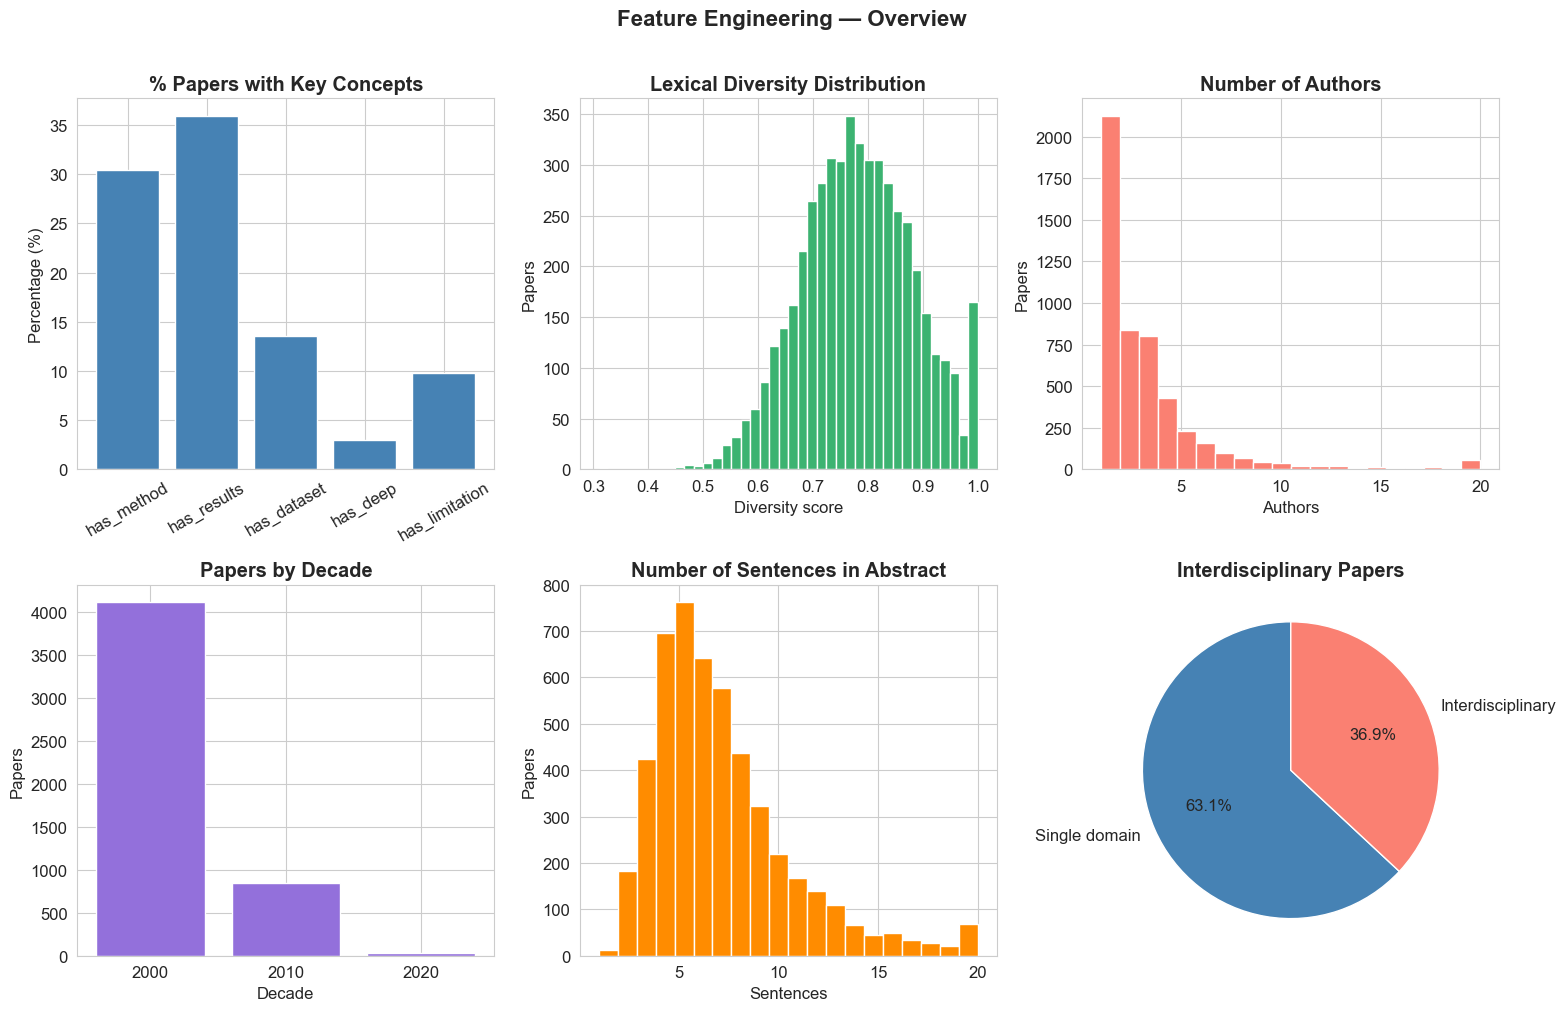

  • Total new features created : 22
  • Text features    : nb_sentences, avg_word_length,
                       lexical_diversity, nb_unique_words
  • Content features : has_method, has_results,
                       has_dataset, has_deep, has_limitation
  • Meta features    : nb_categories, decade,
                       is_recent, title_length
  • Plot saved → reports/feature_engineering.png


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1 — Boolean features distribution
bool_features = ['has_method','has_results','has_dataset',
                 'has_deep','has_limitation']
bool_means = df[bool_features].mean() * 100
axes[0,0].bar(bool_features, bool_means, color='steelblue', edgecolor='white')
axes[0,0].set_title('% Papers with Key Concepts', fontweight='bold')
axes[0,0].set_ylabel('Percentage (%)')
axes[0,0].tick_params(axis='x', rotation=30)

# 2 — Lexical diversity
axes[0,1].hist(df['lexical_diversity'], bins=40,
               color='mediumseagreen', edgecolor='white')
axes[0,1].set_title('Lexical Diversity Distribution', fontweight='bold')
axes[0,1].set_xlabel('Diversity score')
axes[0,1].set_ylabel('Papers')

# 3 — Nb authors
axes[0,2].hist(df['nb_authors'].clip(0, 20), bins=20,
               color='salmon', edgecolor='white')
axes[0,2].set_title('Number of Authors', fontweight='bold')
axes[0,2].set_xlabel('Authors')
axes[0,2].set_ylabel('Papers')

# 4 — Decade distribution
decade_counts = df['decade'].value_counts().sort_index()
axes[1,0].bar(decade_counts.index.astype(str),
              decade_counts.values, color='mediumpurple',
              edgecolor='white')
axes[1,0].set_title('Papers by Decade', fontweight='bold')
axes[1,0].set_xlabel('Decade')
axes[1,0].set_ylabel('Papers')

# 5 — Nb sentences
axes[1,1].hist(df['nb_sentences'].clip(0, 20), bins=20,
               color='darkorange', edgecolor='white')
axes[1,1].set_title('Number of Sentences in Abstract', fontweight='bold')
axes[1,1].set_xlabel('Sentences')
axes[1,1].set_ylabel('Papers')

# 6 — Interdisciplinary
inter_counts = df['is_interdisciplinary'].value_counts()
axes[1,2].pie(inter_counts.values,
              labels=['Single domain','Interdisciplinary'],
              autopct='%1.1f%%',
              colors=['steelblue','salmon'],
              startangle=90)
axes[1,2].set_title('Interdisciplinary Papers', fontweight='bold')

plt.suptitle('Feature Engineering — Overview',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('reports/feature_engineering.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print(f"  • Total new features created : {len(feature_cols)}")
print(f"  • Text features    : nb_sentences, avg_word_length,")
print(f"                       lexical_diversity, nb_unique_words")
print(f"  • Content features : has_method, has_results,")
print(f"                       has_dataset, has_deep, has_limitation")
print(f"  • Meta features    : nb_categories, decade,")
print(f"                       is_recent, title_length")
print(f"  • Plot saved → reports/feature_engineering.png")
print("=" * 60)

### 5.ML Pipeline and Model Comparison

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,accuracy_score, f1_score)
import time

**5.1 : Prepare Data**

In [19]:
top6 = df['main_category'].value_counts().head(6).index
df_ml = df[df['main_category'].isin(top6)].copy()

print(f"\n   Classes selected : {list(top6)}")
print(f"   Total samples    : {len(df_ml)}")
print(f"\n   Class distribution :")
print(df_ml['main_category'].value_counts())

X = df_ml['abstract_clean']
y = df_ml['main_category']

# Train / Test split — 80% / 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f"\n   Train size : {len(X_train)} samples")
print(f"   Test size  : {len(X_test)}  samples")



   Classes selected : ['math', 'astro-ph', 'cond-mat', 'physics', 'hep-ph', 'hep-th']
   Total samples    : 3845

   Class distribution :
main_category
math        999
astro-ph    972
cond-mat    898
physics     345
hep-ph      326
hep-th      305
Name: count, dtype: int64

   Train size : 3076 samples
   Test size  : 769  samples


**5.2 : Define Models**

In [20]:
models = {
    "Naive Bayes": Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
        ('clf',   MultinomialNB())
    ]),
    "Logistic Regression": Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
        ('clf',   LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))
    ]),
    "Linear SVM": Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
        ('clf',   LinearSVC(random_state=RANDOM_SEED, max_iter=2000))
    ]),
    "Random Forest": Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000)),
        ('clf',   RandomForestClassifier(n_estimators=100,random_state=RANDOM_SEED))
    ])
}

print(f"{len(models)} models defined :")
for name in models:
    print(f"- {name}")

4 models defined :
- Naive Bayes
- Logistic Regression
- Linear SVM
- Random Forest


**5.3 : Train and Evaluate all models**

In [ ]:
results = {}

for name, pipeline in models.items():
    print(f"\n Training {name}...")
    start = time.time()

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Metrics
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, average='weighted')
    elapsed = time.time() - start

    # Cross-validation
    cv_scores = cross_val_score(pipeline, X_train, y_train,cv=5, scoring='f1_weighted')

    results[name] = {
        'accuracy'    : acc,
        'f1_weighted' : f1,
        'cv_mean'     : cv_scores.mean(),
        'cv_std'      : cv_scores.std(),
        'train_time'  : elapsed,
        'y_pred'      : y_pred
    }

    print(f"{name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1-weighted  : {f1:.4f}")
    print(f"CV F1 (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"Train time : {elapsed:.1f}s")



 Training Naive Bayes...
Naive Bayes
Accuracy : 0.7802
F1-weighted  : 0.7284
CV F1 (5-fold): 0.7247 ± 0.0088
Train time : 2.7s

 Training Logistic Regression...
Logistic Regression
Accuracy : 0.8544
F1-weighted  : 0.8393
CV F1 (5-fold): 0.8238 ± 0.0065
Train time : 5.1s

 Training Linear SVM...
Linear SVM
Accuracy : 0.8752
F1-weighted  : 0.8693
CV F1 (5-fold): 0.8708 ± 0.0043
Train time : 2.2s

 Training Random Forest...
Random Forest
Accuracy : 0.7945
F1-weighted  : 0.7570
CV F1 (5-fold): 0.7490 ± 0.0107
Train time : 7.8s


**5.4 : Comparison Table**

In [22]:
results_df = pd.DataFrame({
    name: {
        'Accuracy'      : f"{v['accuracy']:.4f}",
        'F1-weighted'   : f"{v['f1_weighted']:.4f}",
        'CV F1 (mean)'  : f"{v['cv_mean']:.4f}",
        'CV F1 (std)'   : f"{v['cv_std']:.4f}",
        'Train time (s)': f"{v['train_time']:.1f}"
    }
    for name, v in results.items()
}).T

print(f"\n{results_df.to_string()}")

# Best model
best_model_name = max(results, key=lambda x: results[x]['f1_weighted'])
print(f"\n Best model : {best_model_name}")
print(f"F1-weighted : {results[best_model_name]['f1_weighted']:.4f}")


                    Accuracy F1-weighted CV F1 (mean) CV F1 (std) Train time (s)
Naive Bayes           0.7802      0.7284       0.7247      0.0088            2.7
Logistic Regression   0.8544      0.8393       0.8238      0.0065            5.1
Linear SVM            0.8752      0.8693       0.8708      0.0043            2.2
Random Forest         0.7945      0.7570       0.7490      0.0107            7.8

 Best model : Linear SVM
F1-weighted : 0.8693


**5.5 : Visualization**

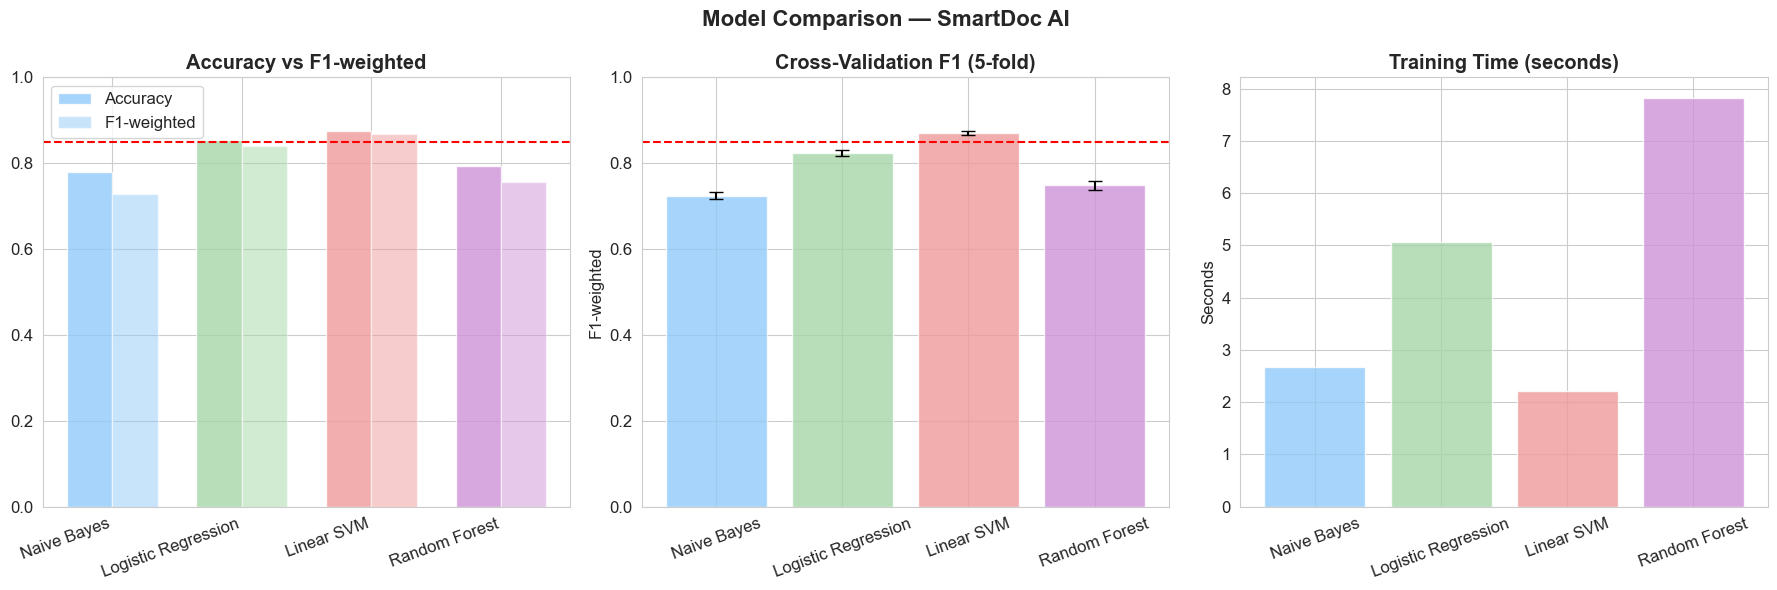

Plot saved → reports/model_comparison.png


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

names      = list(results.keys())
accuracies = [results[n]['accuracy']    for n in names]
f1_scores  = [results[n]['f1_weighted'] for n in names]
cv_means   = [results[n]['cv_mean']     for n in names]
cv_stds    = [results[n]['cv_std']      for n in names]
times      = [results[n]['train_time']  for n in names]

colors = ['#90CAF9','#A5D6A7','#EF9A9A','#CE93D8']

# Accuracy & F1 comparison
x      = np.arange(len(names))
width  = 0.35
axes[0].bar(x - width/2, accuracies, width, label='Accuracy',color=colors, alpha=0.8, edgecolor='white')
axes[0].bar(x + width/2, f1_scores,  width, label='F1-weighted',color=colors, alpha=0.5, edgecolor='white')
axes[0].set_title('Accuracy vs F1-weighted', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=20, ha='right')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].axhline(0.85, color='red', linestyle='--',label='Target (0.85)')

# Cross-validation scores
axes[1].bar(names, cv_means, color=colors, edgecolor='white', alpha=0.8)
axes[1].errorbar(names, cv_means, yerr=cv_stds,
                 fmt='none', color='black', capsize=5)
axes[1].set_title('Cross-Validation F1 (5-fold)', fontweight='bold')
axes[1].set_ylabel('F1-weighted')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=20)
axes[1].axhline(0.85, color='red', linestyle='--')

# Training time
axes[2].bar(names, times, color=colors, edgecolor='white', alpha=0.8)
axes[2].set_title('Training Time (seconds)', fontweight='bold')
axes[2].set_ylabel('Seconds')
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Model Comparison — SmartDoc AI',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → reports/model_comparison.png")

**5.6 Best Model**


   Classification Report :

              precision    recall  f1-score   support

        math       0.94      0.95      0.95       194
    astro-ph       0.85      0.94      0.89       180
    cond-mat       0.94      0.74      0.83        65
     physics       0.77      0.79      0.78        61
      hep-ph       0.89      0.95      0.92       200
      hep-th       0.70      0.46      0.56        69

    accuracy                           0.88       769
   macro avg       0.85      0.81      0.82       769
weighted avg       0.87      0.88      0.87       769



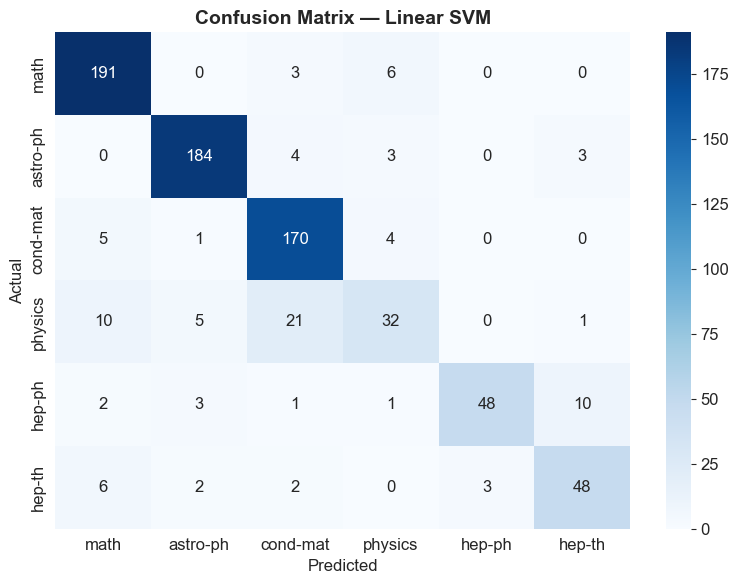

Plot saved → reports/confusion_matrix.png
  • Models tested    : 4
  • Best model       : Linear SVM
  • Best F1          : 0.8693
  • Best Accuracy    : 0.8752
  • Model saved      → models/best_classifier.pkl
  • Plots saved      → reports/


In [24]:
best_pipeline = models[best_model_name]
y_pred_best   = results[best_model_name]['y_pred']

print(f"\n   Classification Report :\n")
print(classification_report(y_test, y_pred_best, target_names=top6))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best, labels=top6)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=top6, yticklabels=top6, ax=ax)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('reports/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → reports/confusion_matrix.png")

# Save best model
import pickle
with open('models/best_classifier.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f)

print("=" * 60)
print(f"  • Models tested    : {len(models)}")
print(f"  • Best model       : {best_model_name}")
print(f"  • Best F1          : {results[best_model_name]['f1_weighted']:.4f}")
print(f"  • Best Accuracy    : {results[best_model_name]['accuracy']:.4f}")
print(f"  • Model saved      → models/best_classifier.pkl")
print(f"  • Plots saved      → reports/")
print("=" * 60)